# Week 3 · 监控篇：给推理服务装上仪表盘

> 🎯 **核心思想：先测量，后优化。** Week 6 的量化、Week 7 的投机解码，所有"性能提升"都只能靠本周的监控来证明——**没有测量的优化是玄学**。
>
> 本 Notebook 特色：**每个 PromQL 查询都打在真实运行的 Prometheus 上**，你看到的每一条曲线都是这台 5090 上 vLLM 的实时数据。
>
> 前置：vLLM 服务 (:8000)、Prometheus (:9090)、Grafana (:3000) 都在运行。
> 如果监控没跑，先在终端执行：`bash /workspace/start_monitoring.sh`

## 0. 监控体系架构（30 秒版）

```
vLLM (:8000) ──/metrics──> Prometheus (:9090) ──PromQL──> Grafana (:3000) ──> 你的浏览器
   产生指标                  存成时序数据              画成图
```

- **vLLM** 自带 `/metrics` 端点，吐出 98 个 `vllm:*` 指标（文本格式）
- **Prometheus** 每 5 秒抓一次，存成带时间戳的数列（时序数据库）
- **Grafana** 用 PromQL 查询语言把数列画成曲线

先验证整条链路是否活着：

In [1]:
import urllib.request, json, time

def prom_query(expr):
    """查询 Prometheus 即时值"""
    url = f"http://localhost:9090/api/v1/query?query={urllib.parse.quote(expr)}"
    return json.load(urllib.request.urlopen(url, timeout=10))["data"]["result"]

def prom_range(expr, minutes=30, step=15):
    """查询 Prometheus 时间段数据（画图用）"""
    end, start = time.time(), time.time() - minutes * 60
    url = (f"http://localhost:9090/api/v1/query_range?query={urllib.parse.quote(expr)}"
           f"&start={start}&end={end}&step={step}")
    return json.load(urllib.request.urlopen(url, timeout=10))["data"]["result"]

import urllib.parse

# 健康检查三连
services = {
    "vLLM (:8000)": "http://localhost:8000/v1/models",
    "Prometheus (:9090)": "http://localhost:9090/-/healthy",
    "Grafana (:3000)": "http://localhost:3000/api/health",
}
for name, url in services.items():
    try:
        urllib.request.urlopen(url, timeout=3)
        print(f"✅ {name}")
    except Exception as e:
        print(f"❌ {name} — {e}")

✅ vLLM (:8000)
✅ Prometheus (:9090)
✅ Grafana (:3000)


## 1. 四个必懂指标（Week 3 的灵魂）

| 指标名 | 中文 | 回答的问题 | 理论对应 |
|---|---|---|---|
| `vllm:time_to_first_token_seconds` | TTFT 首字延迟 | 用户等多久看到第一个字？ | prefill，算力瓶颈 |
| `vllm:inter_token_latency_seconds` | ITL 字间延迟 | 输出流不流畅？ | decode，带宽瓶颈 |
| `vllm:num_requests_running` / `_waiting` | 运行中 / 排队中 | 系统在忙还是在堵？ | 连续批处理状态 |
| `vllm:kv_cache_usage_perc` | KV Cache 使用率 | 显存池还剩多少？ | Week 1 显存账本 |

先看看现在跑/排队的请求数和 KV 池水位：

In [2]:
# 调度器实时状态（Scheduler State 面板背后的数据）
for expr, label in [
    ("vllm:num_requests_running", "运行中的请求"),
    ("vllm:num_requests_waiting", "排队中的请求"),
    ("vllm:kv_cache_usage_perc",  "KV Cache 使用率"),
]:
    r = prom_query(expr)
    if r:
        v = float(r[0]["value"][1])
        if "perc" in expr: v *= 100
        print(f"{label:　<12}: {v:,.1f}{'%' if 'perc' in expr else ''}")
    else:
        print(f"{label:　<12}: 暂无数据（发几个请求就有了）")

print()
print("🔑 判读口诀：waiting 涨 + TTFT 涨 = 排队了；")
print("            running 不动 + KV 使用率接近 100% = 要抢占了（preemption）")

运行中的请求　　　　　　: 0.0
排队中的请求　　　　　　: 0.0
KV Cache 使用率: 0.0%

🔑 判读口诀：waiting 涨 + TTFT 涨 = 排队了；
            running 不动 + KV 使用率接近 100% = 要抢占了（preemption）


## 2. PromQL 实战：从原始指标到"每秒生成多少 token"

原始指标大多是**累计计数器**（counter，只增不减），要用 `rate()` 求变化率才有意义。
比如 token 吞吐 = token 总数的变化率：

In [3]:
# Token 吞吐：生成速率 + prompt 处理速率
for expr, label in [
    ('rate(vllm:generation_tokens_total[1m])', "生成 token 速率（tok/s）"),
    ('rate(vllm:prompt_tokens_total[1m])',     "prompt token 速率（tok/s）"),
]:
    r = prom_query(expr)
    v = float(r[0]["value"][1]) if r else 0
    print(f"{label}: {v:,.1f}")
print()
print("💡 对照实验：另开一个终端跑 python /workspace/bench.py，")
print("   然后重跑本格，看生成速率飙到 5000+ tok/s（64 并发的力量）")

生成 token 速率（tok/s）: 0.0
prompt token 速率（tok/s）: 0.0

💡 对照实验：另开一个终端跑 python /workspace/bench.py，
   然后重跑本格，看生成速率飙到 5000+ tok/s（64 并发的力量）


## 3. 延迟分布：为什么必须看 P95/P99 而不是平均值

TTFT 和 ITL 是**直方图（histogram）**指标——vLLM 把每次延迟扔进不同的桶里。
用 `histogram_quantile()` 可以算出"95% 的请求比多少秒快"：

In [4]:
# TTFT / ITL 的分位数（分位数 = 用户体验的真实刻画）
quantiles = [0.5, 0.95, 0.99]
for metric, cname in [("vllm:time_to_first_token_seconds", "TTFT"),
                      ("vllm:inter_token_latency_seconds", "ITL")]:
    print(f"--- {cname} ---")
    for q in quantiles:
        expr = f'histogram_quantile({q}, rate({metric}_bucket[10m]))'
        r = prom_query(expr)
        if r and r[0]["value"][1] not in ("NaN", "+Inf"):
            print(f"  P{int(q*100)}: {float(r[0]['value'][1])*1000:,.0f} ms")
        else:
            print(f"  P{int(q*100)}: 数据不足")
print()
print("📌 为什么要 P99？平均 50ms 可能掩盖 1% 用户等 5 秒。")
print("   用户记住的永远是最差的那次体验——这就是发布 benchmark 必须报 P50/P95/P99 的原因。")

--- TTFT ---
  P50: 67 ms
  P95: 92 ms
  P99: 160 ms
--- ITL ---
  P50: 17 ms
  P95: 24 ms
  P99: 25 ms

📌 为什么要 P99？平均 50ms 可能掩盖 1% 用户等 5 秒。
   用户记住的永远是最差的那次体验——这就是发布 benchmark 必须报 P50/P95/P99 的原因。


## 4. 画一条真实的吞吐曲线

把最近 30 分钟的生成速率画出来——如果你之前跑过压测，能看到清晰的"并发山峰"：

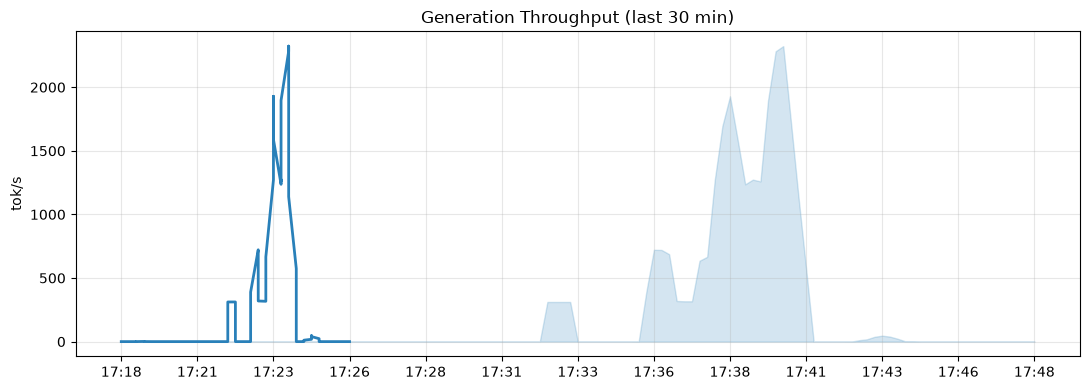

峰值: 2,323 tok/s | 当前: 0 tok/s


In [5]:
import matplotlib.pyplot as plt
from datetime import datetime

r = prom_range('rate(vllm:generation_tokens_total[1m])', minutes=30)
if r:
    ts = [datetime.fromtimestamp(float(t)).strftime("%H:%M") for t, _ in r[0]["values"]]
    vs = [float(v) for _, v in r[0]["values"]]
    plt.figure(figsize=(11, 4))
    plt.plot(ts, vs, lw=2, color="#2980b9")
    plt.fill_between(range(len(vs)), vs, alpha=0.2, color="#2980b9")
    step = max(1, len(ts)//12)
    plt.xticks(range(0, len(ts), step), ts[::step])
    plt.ylabel("tok/s"); plt.title("Generation Throughput (last 30 min)")
    plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig("/workspace/week03_throughput.png", dpi=120); plt.show()
    print(f"峰值: {max(vs):,.0f} tok/s | 当前: {vs[-1]:,.0f} tok/s")
else:
    print("暂无数据——先去跑一轮 bench.py 制造流量")

## 5. Grafana 仪表盘

命令行能查的一切，Grafana 里都画成了实时面板。

**打开方式**：`https://3000-<实例ID>.pod.compshare.cn`（admin/admin）→ Dashboards → **vLLM**

12 个官方面板与指标的对应关系（周四作业：每个面板说出它查的是哪个指标）：

| 面板 | 指标 | 看什么 |
|---|---|---|
| TTFT Latency | `time_to_first_token_seconds` | prefill 健康度 |
| Inter Token Latency | `inter_token_latency_seconds` | decode 流畅度 |
| Token Throughput | `generation_tokens_total` | 系统产能 |
| Scheduler State | `num_requests_running/waiting` | 是否排队 |
| Cache Utilization | `kv_cache_usage_perc` | 显存水位 |
| Queue Time | `request_queue_time_seconds` | 用户排队多久 |
| E2E Latency | `e2e_request_latency_seconds` | 端到端总耗时 |

> ⚠️ **没有定义的指标不要上面板**——每个面板必须能回答一个具体问题，否则就是装饰。

## 6. 课后实验（各 5 分钟）

1. **看连续批处理**：跑 `python /workspace/bench.py`，盯 Scheduler State 面板看 running 爬上 64
2. **找抢占**：重启 vLLM 时加 `--max-num-seqs 8`，再跑 64 并发，观察 waiting 暴涨——这就是"系统被打爆"的样子
3. **亲手写 PromQL**：在 Prometheus (:9090/graph) 里试 `histogram_quantile(0.99, rate(vllm:inter_token_latency_seconds_bucket[5m]))`

## 7. 下一站

➡️ **Week 4**：部署第二个引擎 SGLang，和 vLLM 正面对比前缀缓存性能。
监控不用动——两个引擎都吐 Prometheus 指标，加一行 scrape 配置就能同屏对比。

## 8. 运维备忘

```bash
# 一键启动/检查监控栈（vLLM + Prometheus + Grafana）
bash /workspace/start_monitoring.sh

# 日志位置
tail -f /workspace/vllm.log              # vLLM
tail -f /opt/monitoring/prometheus.log   # Prometheus
tail -f /opt/monitoring/grafana.log      # Grafana
```